In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\welcome


In [5]:
import pandas as pd
df = pd.read_csv(r'C:\Users\welcome\Documents\creditcard.csv')
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [6]:
# Fraud vs Normal kitne hain 
print(df['Class'].value_counts())
print("\nFraud percentage:")
print(df['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


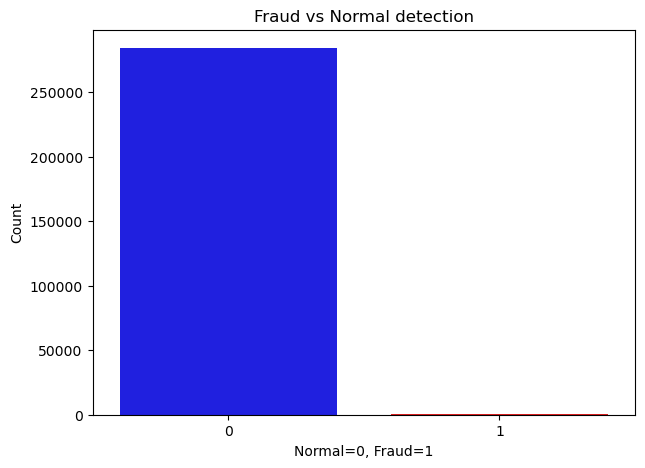

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
sns.countplot(x='Class',hue='Class',data=df, palette=['blue','red'],legend=False)
plt.title('Fraud vs Normal detection')
plt.xlabel('Normal=0, Fraud=1')
plt.ylabel('Count')
plt.show()

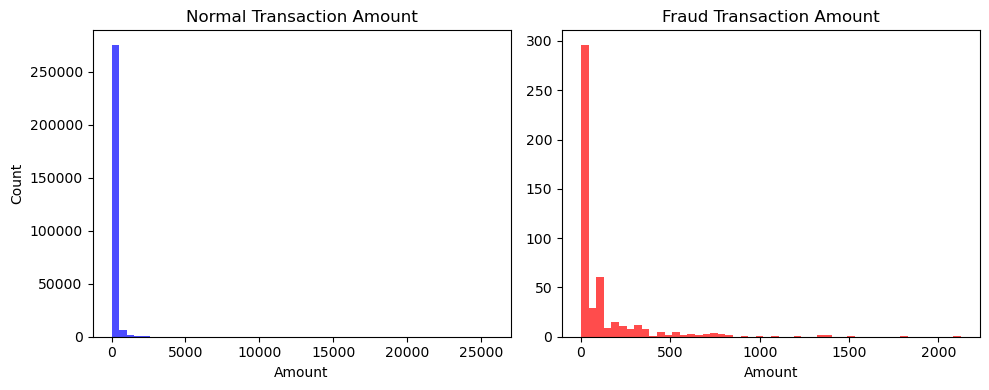

In [14]:
# Fraud aur Normal ka amount compare karo
plt.figure(figsize=(10,4))

# Normal transactions ka amount
plt.subplot(1,2,1)
plt.hist(df[df['Class']==0]['Amount'], 
         bins=50, color='blue', alpha=0.7)
plt.title('Normal Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Count')

# Fraud transactions ka amount  
plt.subplot(1,2,2)
plt.hist(df[df['Class']==1]['Amount'], 
         bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amount')
plt.xlabel('Amount')

plt.tight_layout()
plt.show()

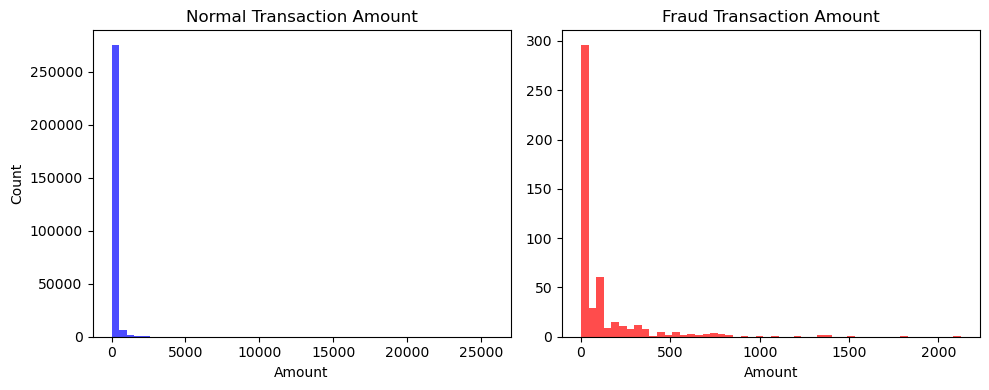

In [15]:
# Fraud aur Normal ka amount compare karo
plt.figure(figsize=(10,4))

# Normal transactions ka amount
plt.subplot(1,2,1)
plt.hist(df[df['Class']==0]['Amount'], 
         bins=50, color='blue', alpha=0.7)
plt.title('Normal Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Count')

# Fraud transactions ka amount  
plt.subplot(1,2,2)
plt.hist(df[df['Class']==1]['Amount'], 
         bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amount')
plt.xlabel('Amount')

plt.tight_layout()
plt.show()

In [16]:
# X = input features, y = output target
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX columns:", X.columns.tolist())

X shape: (284807, 30)
y shape: (284807,)

X columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [17]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y.value_counts())

sm = SMOTE(random_state=42)
X_balanced, y_balanced = sm.fit_resample(X, y)

print("\nAfter SMOTE:")
print(y_balanced.value_counts())

Before SMOTE:
Class
0    284315
1       492
Name: count, dtype: int64

After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (454904, 30)
Testing data: (113726, 30)
Training labels: (454904,)
Testing labels: (113726,)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Model train ho raha hai...")
print("Thoda wait karo — 1-2 minutes lagenge!")

model.fit(X_train, y_train)

print("Model train ho gaya!")

Model train ho raha hai...
Thoda wait karo — 1-2 minutes lagenge!
Model train ho gaya!


Accuracy: 99.99 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



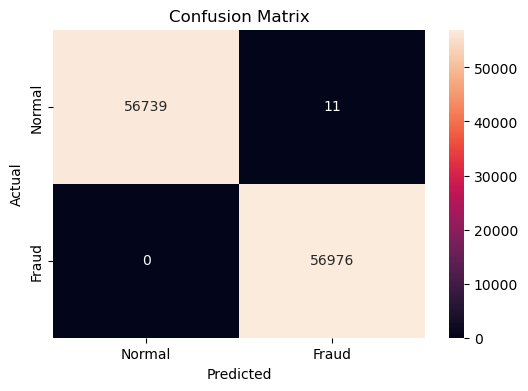

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", round(model.score(X_test, y_test)*100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [22]:
import pickle

pickle.dump(model, open('fraud_model.pkl', 'wb'))
print("Model save ho gaya!")

Model save ho gaya!


In [23]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
